# Synthetic NCS gas network optimization

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/process/norwegian_ncs_gas_network_optimization.ipynb)

This executed example demonstrates the implementation sequence behind
NeqSim issues #2663–#2667:

1. conservative component-molar-flow mixing;
2. edge-local composition and thermal hydraulics;
3. typed quality checks at a named delivery point;
4. bounded whole-network candidate evaluation;
5. multi-period EOS linepack packing, drafting, and restoration.

Facility names are descriptive public context only. Compositions, dimensions,
limits, nominations, and operating cases are synthetic and are not asset
forecasts or contractual specifications.

## Setup

The notebook uses the public `neqsim` Python package and JPype bridge. When run
from a source checkout, workspace classes should precede the packaged jar on
the JVM classpath.

**Execution source:** Run all cells in a fresh Python kernel with Git and JDK 17+. An existing compiled NeqSim checkout is used first. Otherwise setup fetches and builds the documentation source at `refs/pull/3597/head`, which contains fixes exercised here. Set `NEQSIM_GIT_REF` before running to validate another commit or ref. The public Python package supplies the bridge and helpers; its bundled Java library alone is not the validated source for this notebook. The first source build can take several minutes.


In [1]:
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

# Install Python packages with this notebook kernel. Java runs from the
# validated documentation source below, ahead of the package's bundled JAR.
required = {"neqsim": "neqsim>=3.20.0,<4", "numpy": "numpy",
            "scipy": "scipy>=1.14,<2", "matplotlib": "matplotlib", "pandas": "pandas"}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

candidate = Path(os.environ.get("NEQSIM_PROJECT_ROOT", Path.cwd())).resolve()
PROJECT_ROOT = next((p for p in [candidate, *candidate.parents]
                     if (p / "pom.xml").is_file()
                     and (p / "devtools/neqsim_dev_setup.py").is_file()), None)
if PROJECT_ROOT is None:
    # The public package alone predates fixes exercised by these examples.
    # Use the validated documentation PR's source; override with another fixed
    # commit or ref through NEQSIM_GIT_REF when validating a newer revision.
    source_ref = os.environ.get("NEQSIM_GIT_REF", "refs/pull/3597/head")
    PROJECT_ROOT = Path(tempfile.mkdtemp(prefix="neqsim-optimization-"))
    subprocess.check_call(["git", "init", "-q", str(PROJECT_ROOT)])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "remote", "add", "origin",
                           "https://github.com/equinor/neqsim.git"])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "fetch", "--depth", "1",
                           "origin", source_ref])
    subprocess.check_call(["git", "-C", str(PROJECT_ROOT), "checkout", "--quiet",
                           "--detach", "FETCH_HEAD"])
    print(f"Fetched NeqSim documentation source: {source_ref}")

if not (PROJECT_ROOT / "target/classes/neqsim/thermo/system/SystemSrkEos.class").is_file():
    # Requires Git and JDK 17+ before the first source build.
    # The Maven wrapper downloads its own Maven distribution and dependencies.
    wrapper = "mvnw.cmd" if os.name == "nt" else "mvnw"
    build = subprocess.run(
        [str(PROJECT_ROOT / wrapper), "-q", "-DskipTests", "compile",
         "dependency:build-classpath", "-DincludeScope=runtime",
         "-Dmdep.outputFile=target/neqsim-dev-classpath.txt",
         f"-Dmdep.pathSeparator={os.pathsep}"],
        cwd=PROJECT_ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    if build.returncode:
        raise RuntimeError("NeqSim source build failed:\n" + build.stdout[-12000:])

os.environ["NEQSIM_PROJECT_ROOT"] = str(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT,
                              recompile=False, verbose=False))
NEQSIM_MODE = "workspace target/classes"
from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_figure(filename):
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

print(f"NeqSim source: {NEQSIM_MODE}")


import jpype
import pandas as pd


All NeqSim classes imported OK
NeqSim source: workspace target/classes


In [2]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
LoopedPipeNetwork = jneqsim.process.equipment.network.LoopedPipeNetwork
NetworkQualityProfile = jneqsim.process.equipment.network.NetworkQualityProfile
GasQualityMetric = jneqsim.process.equipment.network.GasQualityMetric
QualityReference = jneqsim.process.equipment.network.QualityReference
GasLinepackState = jneqsim.process.equipment.network.GasLinepackState
NetworkPlanningHorizon = jneqsim.process.equipment.network.NetworkPlanningHorizon
NetworkOptimizer = jneqsim.process.equipment.network.NetworkOptimizer
NetworkDecisionVariable = jneqsim.process.equipment.network.NetworkDecisionVariable
NetworkObjectives = jneqsim.process.equipment.network.NetworkObjectives
NetworkConstraints = jneqsim.process.equipment.network.NetworkConstraints

print("Network, quality, optimizer, and planning classes loaded")

Network, quality, optimizer, and planning classes loaded


## Fluids and coupled network

The two source fluids use the same named component slate but have different
molecular weights and temperatures. Junction mixing therefore cannot be done
by mass-weighting mole fractions. Route arrays use metres, kelvin, and
W/(m² K).

In [3]:
def make_gas(temperature_k, pressure_bara, composition):
    fluid = SystemSrkEos(temperature_k, pressure_bara)
    for name, amount in composition.items():
        fluid.addComponent(name, amount)
    fluid.setMixingRule("classic")
    return fluid


lean = make_gas(293.15, 80.0, {
    "methane": 0.94,
    "ethane": 0.03,
    "propane": 0.01,
    "n-butane": 0.005,
    "CO2": 0.015,
})
rich = make_gas(303.15, 75.0, {
    "methane": 0.72,
    "ethane": 0.15,
    "propane": 0.08,
    "n-butane": 0.035,
    "CO2": 0.015,
})

network = LoopedPipeNetwork("Synthetic NCS gas network")
network.setFluidTemplate(lean)
network.setSolverType(LoopedPipeNetwork.SolverType.NEWTON_RAPHSON)
network.setMaxIterations(200)
network.setTolerance(500.0)  # Pa
network.setCompositionalHydraulicsEnabled(True)
network.setThermalHydraulicsEnabled(True)
network.setCouplingMaxIterations(8)
network.setCouplingTolerances(1.0e-3, 100.0)  # kg/s, Pa

network.addSourceNode("lean source", 80.0, 0.0)
network.addSourceNode("rich source", 75.0, 0.0)
network.addJunctionNode("Kollsnes-like hub")
network.addFixedPressureSinkNode("delivery", 45.0)
network.addPipe(
    "lean source", "Kollsnes-like hub", "lean corridor", 4000.0, 0.25
)
network.addPipe(
    "rich source", "Kollsnes-like hub", "rich corridor", 4000.0, 0.25
)
export_line = network.addPipe(
    "Kollsnes-like hub", "delivery", "export corridor", 8000.0, 0.35
)
export_line.setElevationProfile(
    [0.0, 4000.0, 8000.0], [-100.0, -250.0, -30.0]
)
export_line.setAmbientTemperatureProfile(
    [0.0, 8000.0], [278.15, 283.15]
)
export_line.setHeatTransferProfile(
    [0.0, 8000.0], [4.0, 6.0]
)
network.setNodeFluid("lean source", lean)
network.setNodeFluid("rich source", rich)

network.run()
coupling = network.getNetworkCouplingReport()
mixing = coupling.getCompositionReport()

flow_rows = []
for edge_name in network.getPipeNames():
    edge = network.getPipe(str(edge_name))
    flow_rows.append({
        "edge": str(edge_name),
        "flow_kg_s": float(edge.getFlowRate()),
        "head_loss_bar": float(edge.getHeadLoss()) / 1.0e5,
        "outlet_temperature_C": float(edge.getOutletTemperature()) - 273.15,
    })
flow_table = pd.DataFrame(flow_rows)
flow_table

Out[3]: 
              edge  flow_kg_s  head_loss_bar  outlet_temperature_C
0    lean corridor  47.026201      14.788904             13.638455
1    rich corridor  44.027858       9.788904             24.244798
2  export corridor  91.054058      20.211055              6.252897


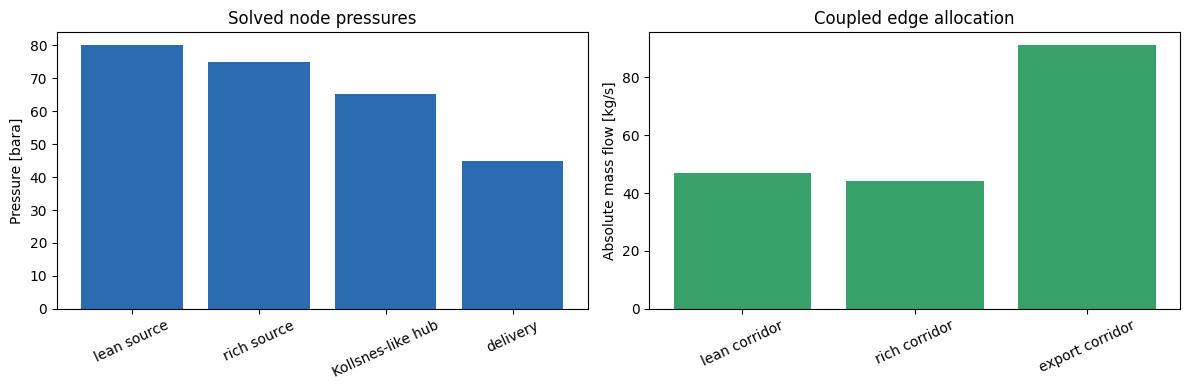

In [4]:
node_names = ["lean source", "rich source", "Kollsnes-like hub", "delivery"]
node_pressures = [float(network.getNodePressure(name)) for name in node_names]
edge_names = flow_table["edge"].tolist()
edge_flows = flow_table["flow_kg_s"].abs().tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(node_names, node_pressures, color="#2b6cb0")
axes[0].set_ylabel("Pressure [bara]")
axes[0].set_title("Solved node pressures")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(edge_names, edge_flows, color="#38a169")
axes[1].set_ylabel("Absolute mass flow [kg/s]")
axes[1].set_title("Coupled edge allocation")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

The coupled report distinguishes inner hydraulic convergence from outer
flow/pressure/temperature and composition residuals. The mixed export inlet is
a flashed, property-initialized fluid.

In [5]:
export_fluid = network.getPipe("export corridor").getInletFluid()
mix_summary = pd.Series({
    "coupled_converged": bool(coupling.isConverged()),
    "outer_iterations": int(coupling.getOuterIterations()),
    "max_flow_residual_kg_s": float(coupling.getMaxFlowResidualKgS()),
    "max_pressure_residual_Pa": float(coupling.getMaxPressureResidualPa()),
    "max_component_molar_residual_mol_s": float(
        mixing.getMaxComponentBalanceResidualMolS()
    ),
    "max_component_mass_residual_kg_s": float(
        mixing.getMaxComponentMassBalanceResidualKgS()
    ),
    "export_methane_mol_fraction": float(
        export_fluid.getComponent("methane").getz()
    ),
    "export_density_kg_m3": float(export_fluid.getDensity("kg/m3")),
    "export_viscosity_Pa_s": float(export_fluid.getViscosity("kg/msec")),
})
mix_summary.to_frame("value")

Out[5]: 
                                        value
coupled_converged                        True
outer_iterations                            5
max_flow_residual_kg_s               0.000413
max_pressure_residual_Pa              11.1275
max_component_molar_residual_mol_s        0.0
max_component_mass_residual_kg_s          0.0
export_methane_mol_fraction          0.847169
export_density_kg_m3                64.112886
export_viscosity_Pa_s                0.000013


## Named quality specification

This synthetic profile demonstrates explicit ISO 6976 reference temperatures,
CO₂, and hydrocarbon dew point at an absolute/gauge-aware pressure reference.
The broad limits are educational, not commercial acceptance criteria.

In [6]:
profile = NetworkQualityProfile("Synthetic delivery profile")
profile.withEffectivePeriod("education-v1", "2026-01-01", None)
profile.withProvenance("Synthetic public-data example")
profile.addUpperLimit(GasQualityMetric.CO2_MOLE_PERCENT, 2.5, "mol%")
profile.addRange(
    GasQualityMetric.WOBBE_INDEX,
    35.0,
    60.0,
    "MJ/Sm3",
    QualityReference().withIso6976Reference(15.0, 15.0),
)
profile.addUpperLimit(
    GasQualityMetric.HYDROCARBON_DEW_POINT_TEMPERATURE,
    20.0,
    "C",
    QualityReference.atPressure(50.0, "barg"),
)
network.setQualityProfile("delivery", profile)
network.run()
quality = network.getQualityComplianceReport("delivery")

quality_rows = []
for item in quality.getResults():
    quality_rows.append({
        "metric": str(item.getMetricKey()),
        "value": None if item.getValue() is None else float(item.getValue()),
        "unit": str(item.getUnit()),
        "lower": None if item.getLowerLimit() is None else float(item.getLowerLimit()),
        "upper": None if item.getUpperLimit() is None else float(item.getUpperLimit()),
        "margin": None if item.getMargin() is None else float(item.getMargin()),
        "status": str(item.getStatus()),
        "method": str(item.getMethod()),
    })
quality_table = pd.DataFrame(quality_rows)
quality_table

Out[6]: 
                           metric  ...                                       method
0                  co2MolePercent  ...                              EOS composition
1                      wobbeIndex  ...                                     ISO 6976
2  hydrocarbonDewPointTemperature  ...  EOS hydrocarbon dew-point temperature flash

[3 rows x 8 columns]


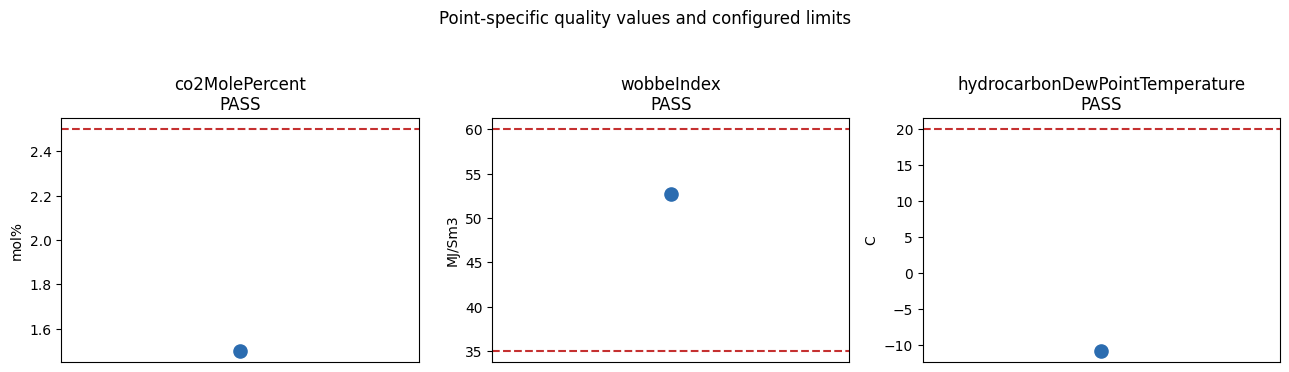

In [7]:
fig, axes = plt.subplots(1, len(quality_rows), figsize=(13, 3.5))
for ax, row in zip(axes, quality_rows):
    value = row["value"]
    lower = row["lower"]
    upper = row["upper"]
    ax.scatter([0], [value], s=90, color="#2b6cb0", zorder=3)
    if lower is not None:
        ax.axhline(lower, color="#c53030", linestyle="--", label="lower")
    if upper is not None:
        ax.axhline(upper, color="#c53030", linestyle="--", label="upper")
    ax.set_xticks([])
    ax.set_ylabel(row["unit"])
    ax.set_title(f'{row["metric"]}\n{row["status"]}')
fig.suptitle("Point-specific quality values and configured limits", y=1.05)
fig.tight_layout()
plt.show()

## Bounded candidate evaluation

The optimizer API evaluates hydraulic and quality constraints on the same
candidate. Availability values act as route derating decisions here. State is
restored after evaluation.

In [8]:
optimizer = NetworkOptimizer(network)
optimizer.addDecisionVariable(NetworkDecisionVariable(
    "edge.lean.availability",
    NetworkDecisionVariable.Type.EDGE_AVAILABILITY,
    "lean corridor",
    "-",
    NetworkDecisionVariable.RateBasis.NONE,
    0.2,
    1.0,
))
optimizer.addDecisionVariable(NetworkDecisionVariable(
    "edge.rich.availability",
    NetworkDecisionVariable.Type.EDGE_AVAILABILITY,
    "rich corridor",
    "-",
    NetworkDecisionVariable.RateBasis.NONE,
    0.2,
    1.0,
))
optimizer.addObjective(NetworkObjectives.maximizeThroughput(1.0))
optimizer.addConstraint(NetworkConstraints.convergence())
optimizer.addConstraint(NetworkConstraints.qualityCompliance(True))

candidate = optimizer.evaluateCandidate([0.90, 0.75])
candidate_summary = pd.Series({
    "feasible": bool(candidate.isFeasible()),
    "solver_converged": bool(candidate.isSolverConverged()),
    "objective_kg_hr": float(candidate.getObjectiveValue()),
    "penalty": float(candidate.getPenalty()),
    "restored_lean_availability": float(
        network.getPipe("lean corridor").getAvailability()
    ),
    "restored_rich_availability": float(
        network.getPipe("rich corridor").getAvailability()
    ),
})
candidate_summary.to_frame("value")

Out[8]: 
                                    value
feasible                             True
solver_converged                     True
objective_kg_hr             298489.540718
penalty                               0.0
restored_lean_availability            1.0
restored_rich_availability            1.0


## Three-period EOS linepack

The first period packs the export line, the second drafts it, and the third
restores the initial mass. The inventory state reports mass, moles, standard
volume, pressure, temperature, composition, pipe volume, and $Z$.

In [9]:
initial = GasLinepackState.fromSolvedState(network, "export corridor")
base_flow = abs(float(network.getPipe("export corridor").getFlowRate()))

horizon = NetworkPlanningHorizon(network)
horizon.addHourlyPeriods("2026-01-01T00:00:00Z", 3)
horizon.setInitialLinepack("export corridor", initial)
horizon.addPipeFlowSchedule(
    "export corridor",
    [base_flow + 2.0, base_flow - 4.0, base_flow + 2.0],
    [base_flow, base_flow, base_flow],
    "kg/s",
)
horizon.setTerminalLinepackTarget(
    "export corridor", initial.getMassKg()
)
schedule = horizon.optimize()

linepack_rows = [{
    "boundary": "initial",
    "mass_kg": float(initial.getMassKg()),
    "pressure_bara": float(initial.getPressurePa()) / 1.0e5,
    "Z": float(initial.getCompressibilityFactor()),
}]
for period_result in schedule.getPeriods():
    state = period_result.getClosingLinepack().get("export corridor")
    linepack_rows.append({
        "boundary": f'period {int(period_result.getPeriod().getIndex()) + 1}',
        "mass_kg": float(state.getMassKg()),
        "pressure_bara": float(state.getPressurePa()) / 1.0e5,
        "Z": float(state.getCompressibilityFactor()),
    })
linepack_table = pd.DataFrame(linepack_rows)
linepack_table

Out[9]: 
   boundary       mass_kg  pressure_bara         Z
0   initial  41727.556385      55.105546  0.833886
1  period 1  48927.556385      64.613934  0.833886
2  period 2  34527.556385      45.596992  0.833886
3  period 3  41727.556385      55.107378  0.833886


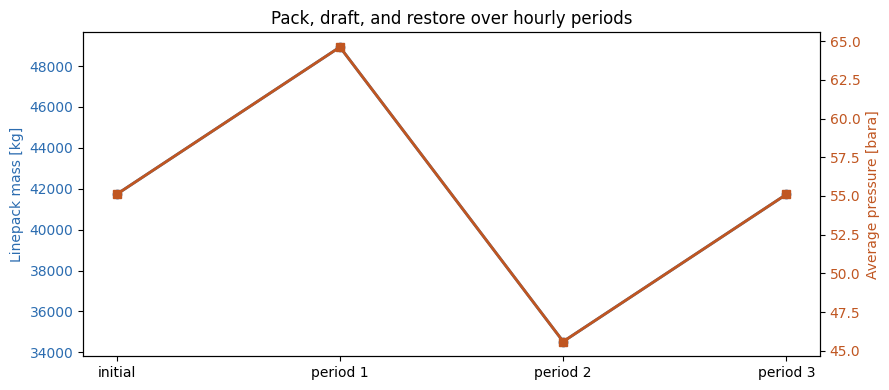

In [10]:
fig, ax1 = plt.subplots(figsize=(9, 4))
x = np.arange(len(linepack_table))
ax1.plot(
    x, linepack_table["mass_kg"], marker="o", linewidth=2,
    color="#2b6cb0", label="linepack mass"
)
ax1.set_ylabel("Linepack mass [kg]", color="#2b6cb0")
ax1.tick_params(axis="y", labelcolor="#2b6cb0")
ax1.set_xticks(x, linepack_table["boundary"])

ax2 = ax1.twinx()
ax2.plot(
    x, linepack_table["pressure_bara"], marker="s", linewidth=2,
    color="#c05621", label="average pressure"
)
ax2.set_ylabel("Average pressure [bara]", color="#c05621")
ax2.tick_params(axis="y", labelcolor="#c05621")
ax1.set_title("Pack, draft, and restore over hourly periods")
fig.tight_layout()
plt.show()

## Validation gates

The notebook finishes with explicit conservation and feasibility checks. A
steady-period linepack model remains a screening tool; rapid transients,
control actions, and detailed thermal fronts require transient validation.

In [11]:
terminal = schedule.getTerminalLinepack().get("export corridor")
assert network.isConverged()
assert coupling.isConverged()
assert mixing.getMaxComponentMassBalanceResidualKgS() < 1.0e-9
assert quality.isCompliant()
assert candidate.isFeasible()
assert schedule.isFeasible()
assert abs(float(terminal.getMassKg()) - float(initial.getMassKg())) < 1.0e-6
assert all(
    abs(float(period.getClosingLinepack().get("export corridor")
              .getMassBalanceResidualKg())) < 1.0e-6
    for period in schedule.getPeriods()
)

{
    "hydraulics": "PASS",
    "component_conservation": "PASS",
    "quality": "PASS",
    "candidate_state_restore": "PASS",
    "linepack_mass_balance": "PASS",
}
assert np.isclose(network.getPipe("lean corridor").getAvailability(), 1.0)
assert np.isclose(network.getPipe("rich corridor").getAvailability(), 1.0)
assert all(np.isfinite(row["mass_kg"]) and row["mass_kg"] > 0.0 for row in linepack_rows)


## Public context and next steps

- [Original public NCS gas-network notebook](https://github.com/EvenSol/NeqSim-Colab/blob/master/notebooks/process/norwegian_ncs_gas_network_optimization.ipynb)
- [Norsk Petroleum pipeline-system overview](https://www.norskpetroleum.no/en/production-and-exports/the-oil-and-gas-pipeline-system/)
- [NeqSim gas-network operations guide](../../../docs/process/gas_network_operations.md)

For asset decisions, replace every synthetic input with governed current data,
validate route and equipment models, and compare the schedule with a transient
pipeline calculation.